<a href="https://colab.research.google.com/github/UtkarshSharma-004/X-ray-lungs-disease-Detection/blob/main/CapConfutionMatrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# /content/drive/MyDrive/Capstone Project/best_model.pth
# /content/drive/MyDrive/Capstone Project/chest_dataset_labels.csv

Imports

In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

Load CSV + Dataset

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Capstone Project/chest_dataset_labels.csv')

test_df = df.iloc[10000:11111]   # same split

class Capstone_Test(Dataset):
    def __init__(self, data):
        self.data = data
        self.transform = transforms.Compose([
            transforms.Resize((128,128)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, y = self.data.iloc[idx][["imagePath","label"]]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        y = torch.tensor(y, dtype=torch.float32)
        return img, y

Test = Capstone_Test(test_df)

Test_loader = DataLoader(Test, batch_size=16, shuffle=False)

Load Model

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 1)

model.load_state_dict(torch.load("/content/drive/MyDrive/Capstone Project/best_model.pth", map_location=device))
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Get Predictions

In [21]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in Test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()

        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

In [26]:
#check threshold
import numpy as np

threshold = np.percentile(all_probs, 90)   # top 10% as disease
print("New Threshold:", threshold)


New Threshold: 0.0003291188


In [30]:
preds = (np.array(all_probs) >= 0.000329).astype(int)

In [28]:
# preds = (np.array(all_probs) >= best_thresh).astype(int)

Confusion Matrix

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(all_labels, preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(all_labels, preds))

Confusion Matrix:
 [[906  98]
 [ 93  14]]

Classification Report:

              precision    recall  f1-score   support

         0.0       0.91      0.90      0.90      1004
         1.0       0.12      0.13      0.13       107

    accuracy                           0.83      1111
   macro avg       0.52      0.52      0.52      1111
weighted avg       0.83      0.83      0.83      1111



Plot Confusion Matrix

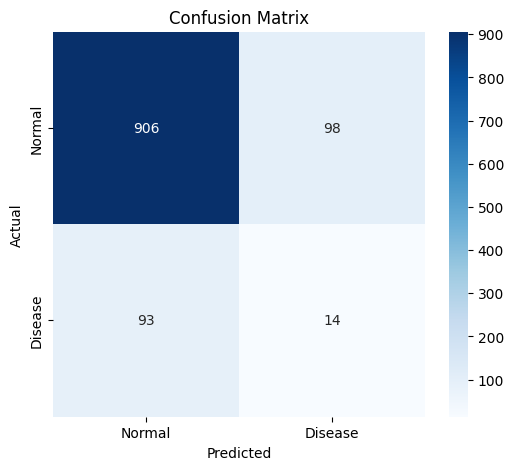

In [32]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Disease'],
            yticklabels=['Normal','Disease'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()